In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
filepath="/Users/Lenovo/OneDrive/Desktop/vscode/datasets_596958_1073629_Placement_Data_Full_Class (1).csv"
df=pd.read_csv(filepath)
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
df.shape

(215, 15)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [5]:
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


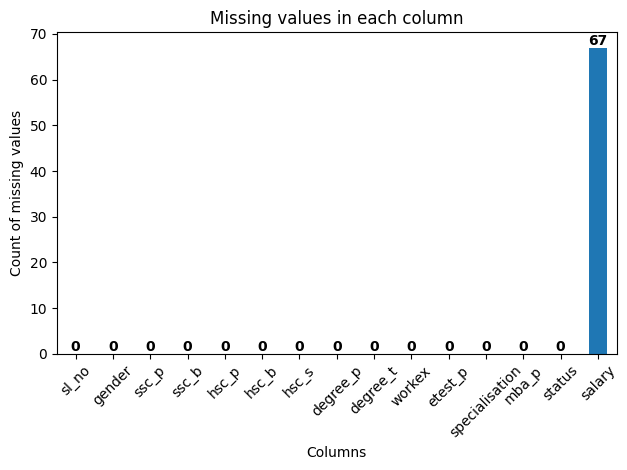

In [6]:
miss=df.isnull().sum()
a=miss.plot(kind='bar')
plt.title("Missing values in each column")
plt.xlabel("Columns")
plt.ylabel("Count of missing values")
plt.xticks(rotation=45)
for index,values in enumerate(miss):
    plt.text(index, values, str(values), ha='center', va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
df=df.drop(columns=['salary'])

In [11]:
print(df.isnull().sum())

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


In [12]:
ssc_p=df['ssc_p'].value_counts()
print(ssc_p)

ssc_p
62.00    11
63.00    10
67.00     9
73.00     9
52.00     9
         ..
55.68     1
41.00     1
83.33     1
43.00     1
80.60     1
Name: count, Length: 103, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29128\2997921254.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ssc_p',data=df,palette="pastel")


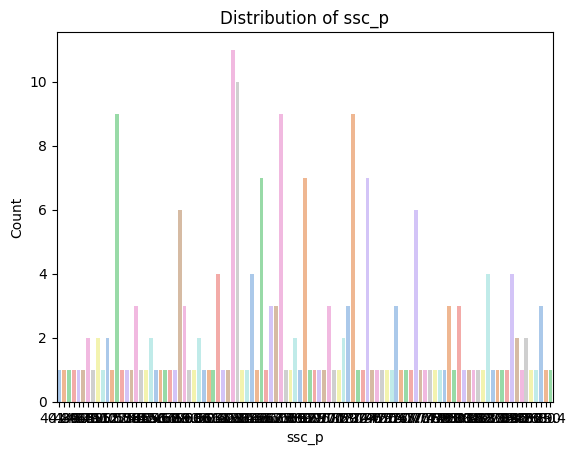

In [13]:
sns.countplot(x='ssc_p',data=df,palette="pastel")
plt.title("Distribution of ssc_p")
plt.xlabel("ssc_p")
plt.ylabel("Count")
plt.show()

In [14]:
gendercount=df['gender'].value_counts()
print(gendercount)

gender
M    139
F     76
Name: count, dtype: int64


In [16]:
gd=df.groupby(['gender','ssc_p']).size()
print(gd)

gender  ssc_p
F       40.89    1
        43.00    1
        45.00    1
        46.00    1
        47.00    2
                ..
M       84.86    1
        85.00    1
        85.80    1
        87.00    2
        89.40    1
Length: 125, dtype: int64


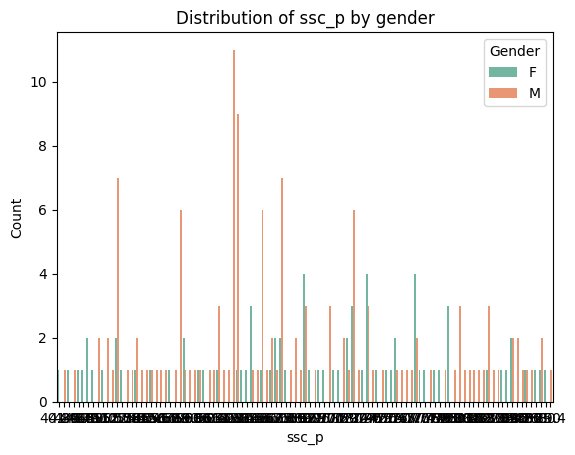

In [17]:
sns.countplot(x='ssc_p',data=df,hue='gender',palette='Set2')
plt.title("Distribution of ssc_p by gender")
plt.xlabel("ssc_p")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()

In [19]:
placecount=df['status'].value_counts()
print(placecount)

status
Placed        148
Not Placed     67
Name: count, dtype: int64


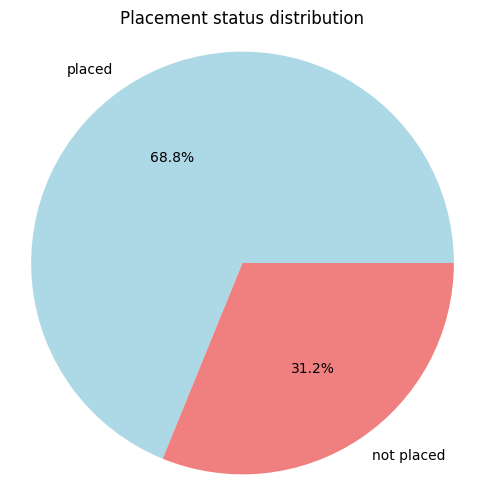

In [22]:
label=['placed','not placed']
plt.figure(figsize=(6,6))
plt.pie(placecount,labels=label,autopct='%1.1f%%',colors=['lightblue','lightcoral'])
plt.title("Placement status distribution")
plt.axis('equal')
plt.show()

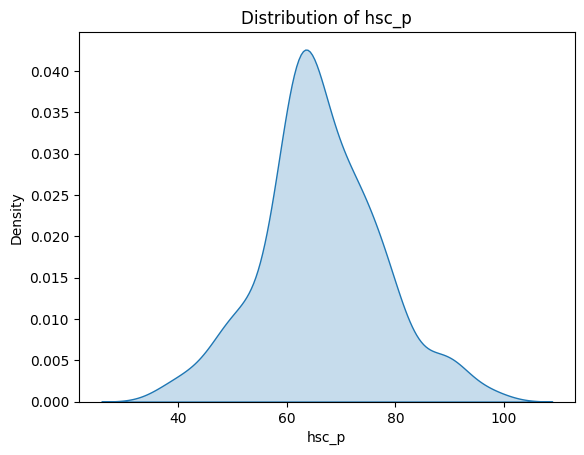

In [23]:
sns.kdeplot(x='hsc_p',fill=True,data=df)
plt.title("Distribution of hsc_p")
plt.xlabel("hsc_p")
plt.ylabel("Density")
plt.show()

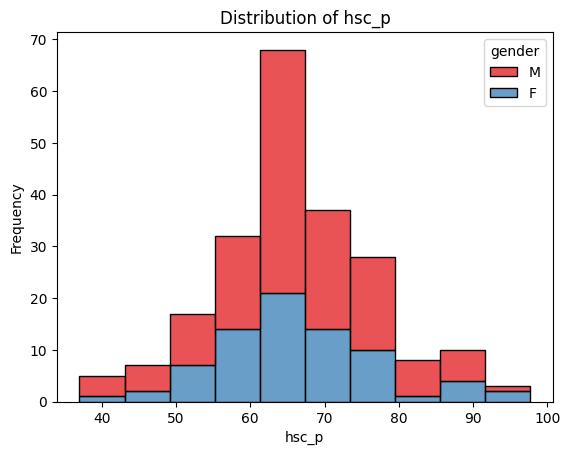

In [26]:
sns.histplot(x='hsc_p',data=df,multiple='stack',hue='gender',bins=10,palette='Set1')
plt.title("Distribution of hsc_p")
plt.xlabel("hsc_p")
plt.ylabel("Frequency")
plt.show()

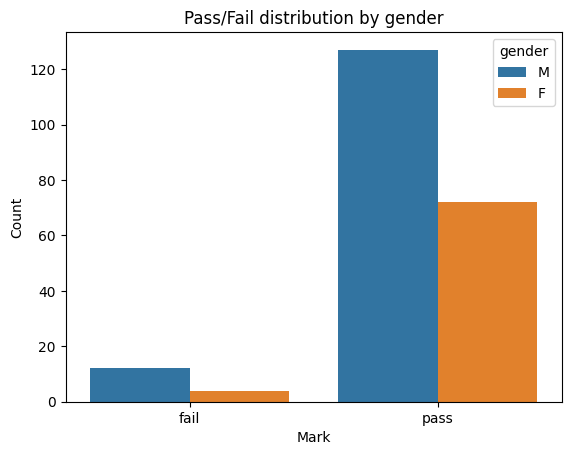

In [28]:
df['Mark']=pd.cut(df['hsc_p'],bins=[0,50,100],labels=['fail','pass'])
sns.countplot(x='Mark',data=df,hue='gender')
plt.title("Pass/Fail distribution by gender")
plt.xlabel("Mark")
plt.ylabel("Count")
plt.show()